In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pertpy as pt

In [2]:
adata = sc.read("../results/adata/09-annotation.h5ad")

In [3]:
# Count cells per sample and cluster
counts = (
    adata.obs
    .groupby(["sample", "leiden_0.15"])
    .size()
    .reset_index(name="n_cells")
)

# Total cells per sample
totals = (
    adata.obs
    .groupby("sample")
    .size()
    .reset_index(name="total_cells")
)

# Merge and compute proportions
df = counts.merge(totals, on="sample")
df["proportion"] = df["n_cells"] / df["total_cells"]

# Add day information (one value per sample)
sample_info = (
    adata.obs[["sample", "day"]]
    .drop_duplicates()
)

df = df.merge(sample_info, on="sample")

/tmp/ipykernel_264133/9032701.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sample", "leiden_0.15"])
/tmp/ipykernel_264133/9032701.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample")


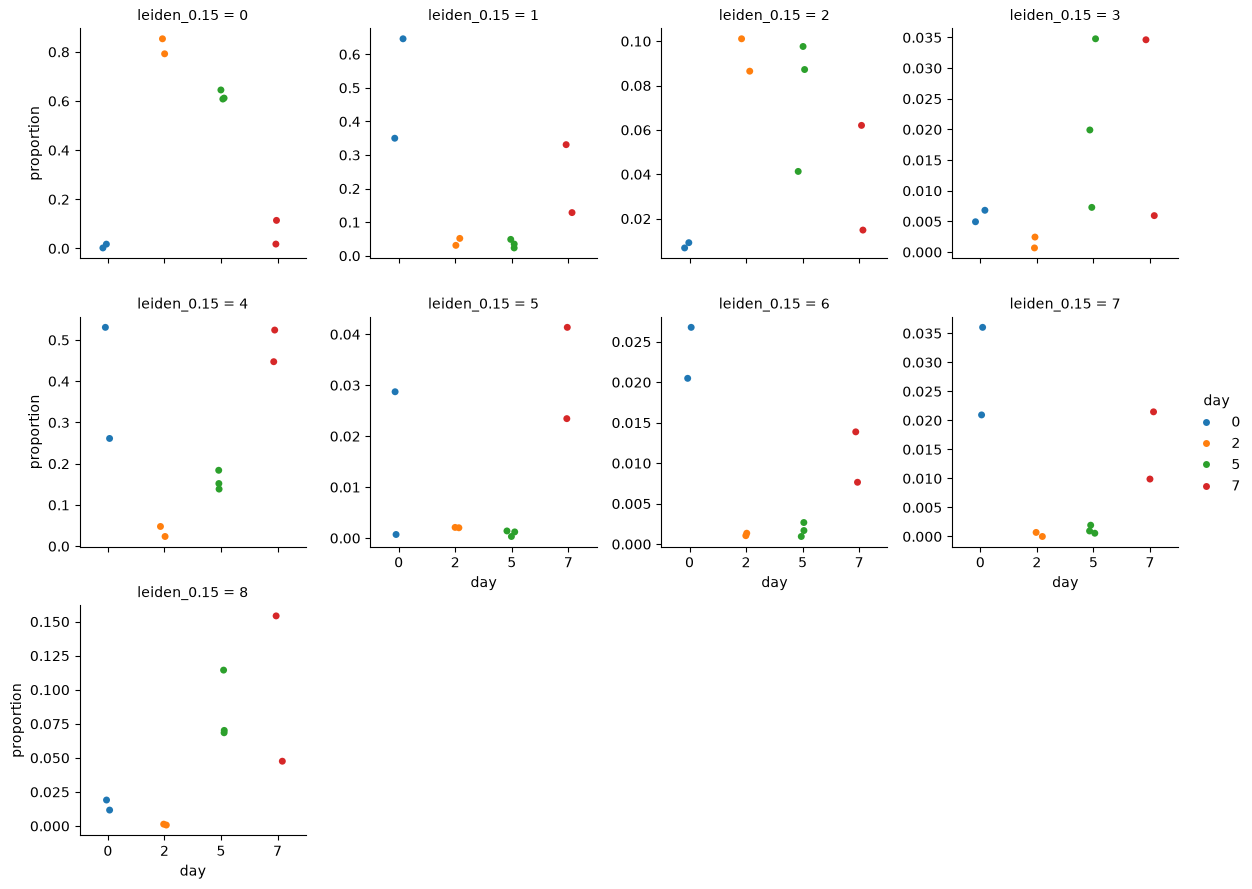

In [4]:
g = sns.catplot(
    data=df,
    x="day",
    y="proportion",
    col="leiden_0.15",
    # kind="box",
    hue="day",
    col_wrap=4,
    sharey=False,
    height=3
)
plt.show()

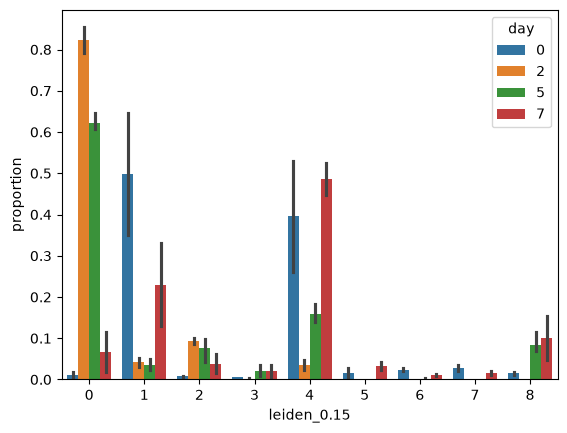

In [5]:
sns.barplot(data=df, x="leiden_0.15", y="proportion", hue="day")
plt.show()

In [6]:
sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="leiden_0.15",
    sample_identifier="sample",
    covariate_obs=["day"]
)


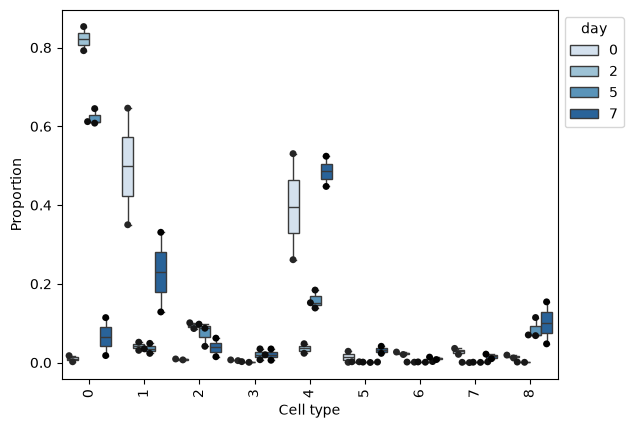

In [7]:
sccoda_model.plot_boxplots(sccoda_data, feature_name="day", add_dots=True)
plt.show()

In [8]:
# sccoda_model.plot_stacked_barplot(adata, feature_name="day")
# plt.show()

In [9]:
sccoda_data = sccoda_model.prepare(sccoda_data, formula="day")

In [10]:
sccoda_model.run_nuts(sccoda_data)

sample: 100%|██████████| 11000/11000 [03:21<00:00, 54.51it/s, 511 steps of size 4.47e-03. acc. prob=0.93] 
/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [11]:
sccoda_model.summary(sccoda_data)

                                          Compositional Analysis summary                                           
┌──────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────┐
│ Name                                         │ Value                                                            │
├──────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────┤
│ Data                                         │ Data: 9 samples, 9 cell types                                    │
│ Reference cell type                          │ 6                                                                │
│ Formula                                      │ day                                                              │
└──────────────────────────────────────────────┴──────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│              Final Parameter  Expected Sample                                                                   │
│ leiden_0.15                                                                                                     │
│ 0                 0.032            72.537                                                                       │
│ 1                 2.807          1163.393                                                                       │
│ 2                -0.071            65.438                                                                       │
│ 3                -0.226            56.042                                                                       │
│ 4                 2.711          1056.900                                                                       │
│ 5                -0.365            48.769                                                                       │
│ 6                -0.258            54.277                                                                       │
│ 7                -0.278            53.202                                                                       │
│ 8                 0.199            85.721                                                                       │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                      Final Parameter  Expected Sample  log2-fold change                                         │
│ Covariate Cell Type                                                                                             │
│ dayT.2    0               5.818          2182.306            4.911                                              │
│           1               0.000           104.077           -3.483                                              │
│           2               3.749           248.686            1.926                                              │
│           3               0.000             5.013           -3.483                                              │
│           4               0.000            94.550           -3.483                                              │
│           5               0.000             4.363           -3.483                                              │
│           6               0.000             4.856           -3.483                                              │
│           7               0.000             4.759           -3.483                                              │
│           8               0.000             7.669           -3.483                                              │
│ dayT.5    0               4.476          1778.010            4.615                                              │
│           1              -1.347            84.442           -3.784                                              │
│           2               2.410           203.235            1.635                                              │
│           3               0.000            15.637           -1.842                                              │
│           4               0.000           294.896           -1.842                                              │
│           5               0.000            13.608           -1.842                                              │
│           6               0.000            15.144           -1.842                                              │
│           7               0.000            14.844           -1.842                                              │
│           8               2.291           236.463            1.464                                              │
│ dayT.7    0               0.000            97.460            0.426                                              │
│           1              -0.877           650.458           -0.839                                              │
│           2               0.000            87.921            0.426                                              │
│           3               0.000            75.297            0.426                                              │
│           4               0.000          1420.037            0.426                                              │
│           5               0.000            65.525            0.426                                              │
│           6               0.000            72.925            0.426                                              │
│           7               0.000            71.481            0.426                                              │
│           8               0.000           115.173            0.426                                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [12]:
sccoda_model.credible_effects(sccoda_data)

Covariate  Cell Type
day[T.2]   0             True
           1            False
           2             True
           3            False
           4            False
           5            False
           6            False
           7            False
           8            False
day[T.5]   0             True
           1             True
           2             True
           3            False
           4            False
           5            False
           6            False
           7            False
           8             True
day[T.7]   0            False
           1             True
           2            False
           3            False
           4            False
           5            False
           6            False
           7            False
           8            False
Name: Final Parameter, dtype: bool

/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


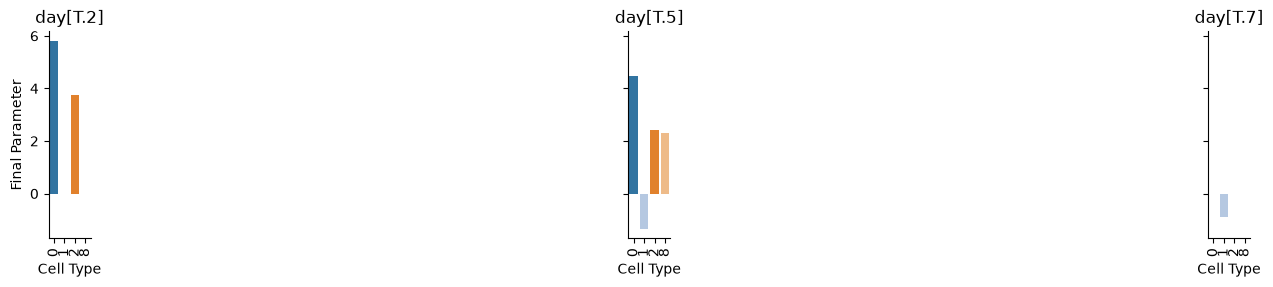

In [13]:
sccoda_model.plot_effects_barplot(sccoda_data, parameter="Final Parameter")

In [14]:
sccoda_model.set_fdr(sccoda_data, est_fdr=0.2)
sccoda_model.summary(sccoda_data)

                                          Compositional Analysis summary                                           
┌──────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────┐
│ Name                                         │ Value                                                            │
├──────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────┤
│ Data                                         │ Data: 9 samples, 9 cell types                                    │
│ Reference cell type                          │ 6                                                                │
│ Formula                                      │ day                                                              │
└──────────────────────────────────────────────┴──────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│              Final Parameter  Expected Sample                                                                   │
│ leiden_0.15                                                                                                     │
│ 0                 0.032            72.537                                                                       │
│ 1                 2.807          1163.393                                                                       │
│ 2                -0.071            65.438                                                                       │
│ 3                -0.226            56.042                                                                       │
│ 4                 2.711          1056.900                                                                       │
│ 5                -0.365            48.769                                                                       │
│ 6                -0.258            54.277                                                                       │
│ 7                -0.278            53.202                                                                       │
│ 8                 0.199            85.721                                                                       │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                      Final Parameter  Expected Sample  log2-fold change                                         │
│ Covariate Cell Type                                                                                             │
│ dayT.2    0               5.818          2182.306            4.911                                              │
│           1               0.000           104.077           -3.483                                              │
│           2               3.749           248.686            1.926                                              │
│           3               0.000             5.013           -3.483                                              │
│           4               0.000            94.550           -3.483                                              │
│           5               0.000             4.363           -3.483                                              │
│           6               0.000             4.856           -3.483                                              │
│           7               0.000             4.759           -3.483                                              │
│           8               0.000             7.669           -3.483                                              │
│ dayT.5    0               4.476          1539.045            4.407                                              │
│           1              -1.347            73.093           -3.992                                              │
│           2               2.410           175.921            1.427                                              │
│           3               1.384            54.006           -0.053                                              │
│           4               0.806           571.795           -0.886                                              │
│           5               0.000            11.779           -2.050                                              │
│           6               0.000            13.109           -2.050                                              │
│           7               0.000            12.849           -2.050                                              │
│           8               2.291           204.682            1.256                                              │
│ dayT.7    0               0.285           122.761            0.759                                              │
│           1              -0.877           616.245           -0.917                                              │
│           2               0.000            83.296            0.348                                              │
│           3               0.000            71.336            0.348                                              │
│           4               0.000          1345.345            0.348                                              │
│           5               0.323            85.771            0.815                                              │
│           6               0.000            69.090            0.348                                              │
│           7               0.000            67.722            0.348                                              │
│           8               0.579           194.711            1.184                                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [15]:
sccoda_model.credible_effects(sccoda_data)

Covariate  Cell Type
day[T.2]   0             True
           1            False
           2             True
           3            False
           4            False
           5            False
           6            False
           7            False
           8            False
day[T.5]   0             True
           1             True
           2             True
           3             True
           4             True
           5            False
           6            False
           7            False
           8             True
day[T.7]   0             True
           1             True
           2            False
           3            False
           4            False
           5             True
           6            False
           7            False
           8             True
Name: Final Parameter, dtype: bool

/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/miniforge3/envs/sc-composition/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


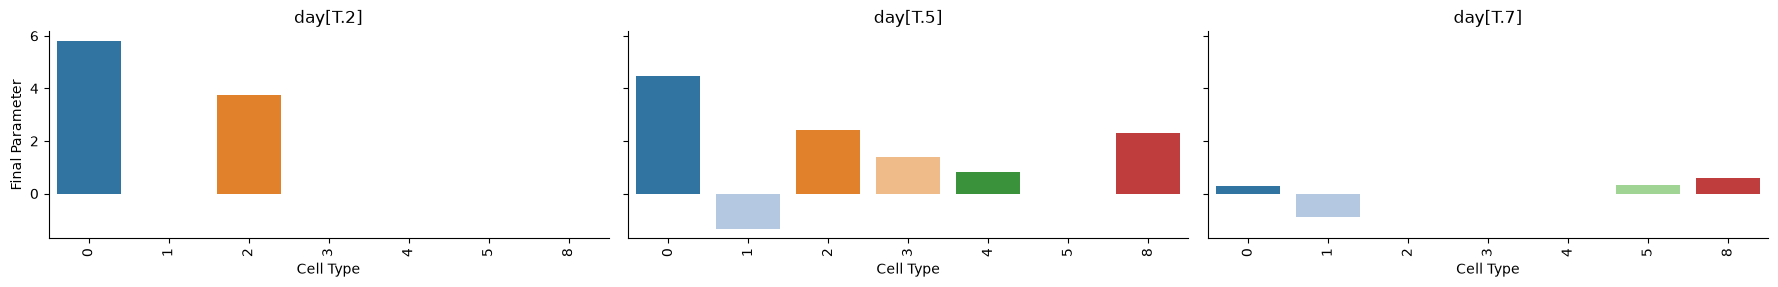

In [16]:
sccoda_model.plot_effects_barplot(sccoda_data, parameter="Final Parameter")